In [ ]:
import os
import numpy as np
import pybullet as p
import pybullet_data
from utils.utils import create_obj

def load_obj(p, obj_name, obj_pos, obj_orn=[0, 0, 0], id=None, scale=1, verbose=0):
    if id is None:
        id = random.randint(1, len(os.listdir(f"objects/{obj_name}")))

    file_path = f"objects/{obj_name}/{obj_name}_{id}/{obj_name}_{id}.urdf"
    obj_orn = p.getQuaternionFromEuler(obj_orn)

    if verbose > 0:
        print(f"Loaded object {obj_name} at pos [{obj_pos[0]:.2f}, {obj_pos[1]:.2f}, {obj_pos[2]:.2f}]")

    obj_id = p.loadURDF(file_path, obj_pos, obj_orn, useFixedBase=False, globalScaling=scale, flags=p.URDF_USE_MATERIAL_COLORS_FROM_MTL)
    p.changeVisualShape(obj_id, -1, rgbaColor=[1, 1, 1, 1])

    return obj_id

def load_table(p, grid_size, obj_pos=[0, 0, 0], verbose=0):
    if grid_size == (100, 100):
        file_path = "objects/table/table_1.1/table_1.1.urdf"
    elif grid_size == (100, 300):
        file_path = "objects/table/table_1.3/table_1.3.urdf"
    else:
        raise ValueError("Invalid grid size. Supported sizes are (100, 100) and (100, 300).")

    if verbose > 0:
        print(f"Loading {file_path}")

    table_id = p.loadURDF(file_path, obj_pos, useFixedBase=True)
    p.changeVisualShape(table_id, -1, rgbaColor=[1, 1, 1, 1])

    return table_id

object_specs = [
    ('knife', 0.04, False),
    ('spoon', 0.04, False),
    ('fork', 0.04, False),
    ('apple', 0.2, False),
    ('banana', 0.2, False),
    ('pear', 0.2, False),
    ('mug', 0.5, True),
    ('paper-cup', 0.3, True),
    ('bowl', 0.4, True),
    ('box', 0.3, True),
    ('basket', 0.3, True),
    ('pan', 0.7, True)
]

for name, mass, convex in object_specs:
    create_obj(name, mass, convex)


In [4]:
import time
from matplotlib import pylab

def get_image(p, camTargetPos=[0,0,0], camDistance=1, ypr=[0, 0, 0], image_size=(640, 480), fig_size=(10, 5)):
    pylab.figure(figsize=fig_size)
    yaw, pitch, roll = ypr
    upAxisIndex = 2
    pixelWidth, pixelHeight = image_size
    nearPlane = 0.01
    farPlane = 100
    fov = 60
    viewMatrix = p.computeViewMatrixFromYawPitchRoll(camTargetPos, camDistance, yaw, pitch, roll, upAxisIndex)
    aspect = pixelWidth / pixelHeight
    projectionMatrix = p.computeProjectionMatrixFOV(fov, aspect, nearPlane, farPlane)
    img_arr = p.getCameraImage(pixelWidth, pixelHeight, viewMatrix, projectionMatrix)
    w = img_arr[0]  #width of the image, in pixels
    h = img_arr[1]  #height of the image, in pixels
    rgb = img_arr[2]  #color data RGB
    dep = img_arr[3]  #depth data
    # print("w=",w,"h=",h)
    np_img_arr = np.reshape(rgb, (h, w, 4))
    np_img_arr = np_img_arr * (1. / 255.)
    # remove grids
    pylab.axis('off')
    pylab.imshow(np_img_arr, interpolation='none', animated=True, label="pybullet")
    pylab.show()

def init(p, mode=p.DIRECT):
	try:
		p.disconnect()
	except:
		pass

	client = p.connect(mode)
	p.setPhysicsEngineParameter(enableFileCaching=0)
	p.setAdditionalSearchPath(pybullet_data.getDataPath())
	p.resetSimulation()
	p.setGravity(0, 0, -9.8)
	p.setRealTimeSimulation(0)
	p.configureDebugVisualizer(p.COV_ENABLE_GUI, 0)
	
	return client

def run(p, time_step=1./240., duration=0):
	for _ in range(int(duration / time_step)):
		p.stepSimulation()

def run_end(p, client):
	time_step = p.getPhysicsEngineParameters()['fixedTimeStep']
	if p.getConnectionInfo(client)['connectionMethod'] == p.GUI:
		while p.isConnected():
			p.stepSimulation()
			time.sleep(time_step)
	try:
		p.disconnect()
	except:
		pass


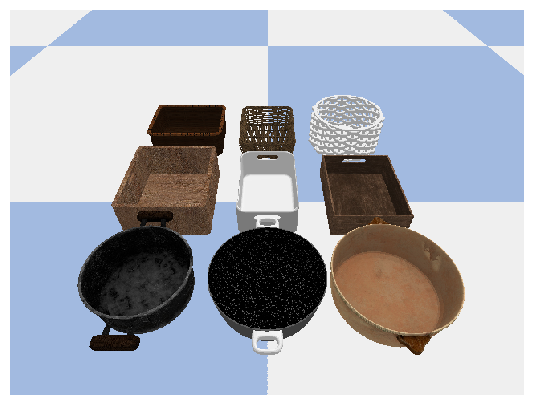

In [ ]:
# client = init(p, p.GUI)
client = init(p, p.DIRECT)
time_step = p.getPhysicsEngineParameters()['fixedTimeStep']

cameraTargetPos = [.5, 0, 0.5]
cameraDistance = 0.1
cameraAngle = [90, -45, 0]

p.resetDebugVisualizerCamera(cameraDistance=cameraDistance, cameraTargetPosition=cameraTargetPos, cameraYaw=cameraAngle[0], cameraPitch=cameraAngle[1])
p.loadURDF("plane.urdf")

z_thr = 0.1
load_obj(p, 'basket', [-0.25, 0.22, z_thr], id=1)
load_obj(p, 'basket', [-0.25, 0., z_thr], id=2)
load_obj(p, 'basket', [-0.25, -0.22, z_thr], id=3)

load_obj(p, 'box', [0.0, 0.22, z_thr], id=1)
load_obj(p, 'box', [0.0, 0., z_thr], id=2)
load_obj(p, 'box', [0.0, -0.22, z_thr], id=3)

load_obj(p, 'pan', [0.25, 0.22, z_thr], id=1)
load_obj(p, 'pan', [0.25, 0., z_thr], id=2)
load_obj(p, 'pan', [0.25, -0.22, z_thr], id=3)

run(p, time_step=time_step, duration=10)
get_image(p, cameraTargetPos, cameraDistance, cameraAngle)
run_end(p, client)